## Project Overview

This notebook documents the data cleaning and preprocessing steps performed on a Mozambican house price dataset (housepricemoz.xlsx). The goal is to prepare a clean, structured dataset suitable for machine learning analysis.

In [2]:
import pandas as pd
import numpy as np
import re


In [3]:
# Load data
df = pd.read_excel("housepricemoz.xlsx")

## Price Column Cleaning

- Removed "MT" currency identifier and spaces from Price column

- Converted "POA" (Price On Application) values to NaN

- Dropped rows with missing Price values

- Converted Price column to numeric type

## Columns Dropped:

- Page, Title, Address, Description, URL (irrelevant for modeling)

- Floor_Size_m2 (inconsistent formatting)

In [4]:
# 1. CLEAN PRICE
df['Price'] = df['Price'].str.replace('MT', '')

In [5]:
df['Price'] = df['Price'].str.replace(' ', '')

In [6]:
# 2. CLEAN FLOOR SIZE
df['Title'].unique


<bound method Series.unique of 0          4 Bedroom House
1       Vacant Land / Plot
2                    House
3       Vacant Land / Plot
4          4 Bedroom House
              ...         
469        2 Bedroom House
470    Commercial Property
471        2 Bedroom House
472        5 Bedroom House
473    Commercial Property
Name: Title, Length: 474, dtype: object>

In [7]:
df = df[df["Title"].str.contains("bedroom", case=False, na=False)]

In [8]:
df["Title"].value_counts()

3 Bedroom House                84
4 Bedroom House                74
2 Bedroom House                40
5 Bedroom House                28
6 Bedroom House                 9
2 Bedroom Apartment / Flat      4
1 Bedroom House                 3
3 Bedroom Apartment / Flat      3
4 Bedroom Townhouse             3
12 Bedroom House                2
12 Bedroom Townhouse            2
4 Bedroom Apartment / Flat      2
16 Bedroom House                1
1 Bedroom Apartment / Flat      1
60 Bedroom Apartment / Flat     1
2 Bedroom Townhouse             1
60 Bedroom House                1
60 Bedroom Townhouse            1
3 Bedroom Townhouse             1
18 Bedroom House                1
72 Bedroom House                1
Name: Title, dtype: int64

In [10]:
df = df[df["Bedrooms"] <= 12]

In [11]:
df.to_csv("cleaned_mozhous.csv", index=False)

In [12]:
df.to_excel("cleaned_mozhous.xlsx", index=False)

In [13]:
df = pd.read_csv('cleaned_mozhouses.csv')

In [14]:
mode = df['Bathrooms'].mode()

In [15]:
mode

0    1.0
Name: Bathrooms, dtype: float64

In [16]:
df['Bathrooms'].mean()

3.0905172413793105

In [15]:
df['Bathrooms'].median()

3.0

In [17]:
df['Bathrooms'].value_counts()  # for specific column

1.0    61
3.0    53
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [18]:
df['Bathrooms'] = df['Bathrooms'].fillna(3)

In [19]:
df['Bathrooms'].value_counts()

3.0    78
1.0    61
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [20]:
df['Location'].value_counts()

Matola Central            129
Praia do Tofo              29
Tete Central               23
Praia da Barra             21
Bilene Central             17
Vilanculos Central         15
Dongane                    11
Inhambane City Central      5
Nacala Central              4
Tofinho                     1
Praia dos Cocos             1
Marracuene                  1
Name: Location, dtype: int64

In [21]:
df.isnull().sum()

Page               0
Title              0
Price              0
Location           0
Address           15
Description        0
Bedrooms           0
Bathrooms          0
Parking          112
Floor_Size_m2     70
URL                0
dtype: int64

In [22]:
df.duplicated().sum() 

0

In [23]:
df['Bathrooms'].value_counts()

3.0    78
1.0    61
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [24]:
df['Parking'].mode()

0    4.0
Name: Parking, dtype: float64

In [25]:
df['Parking'].value_counts()

4.0      36
2.0      33
6.0      15
3.0      13
5.0      12
10.0      9
8.0       8
1.0       7
20.0      5
12.0      3
40.0      2
400.0     1
11.0      1
Name: Parking, dtype: int64

In [26]:
df['Parking'] = df['Parking'].fillna(4)

In [27]:
df['Parking'].value_counts()

4.0      148
2.0       33
6.0       15
3.0       13
5.0       12
10.0       9
8.0        8
1.0        7
20.0       5
12.0       3
40.0       2
400.0      1
11.0       1
Name: Parking, dtype: int64

In [28]:
df['Floor_Size_m2'].value_counts()

8 m²        11
2 500 m²    11
7 m²         9
500 m²       7
200 m²       7
            ..
494 m²       1
2 704 m²     1
51 m²        1
125 m²       1
4 800 m²     1
Name: Floor_Size_m2, Length: 97, dtype: int64

<Axes: >

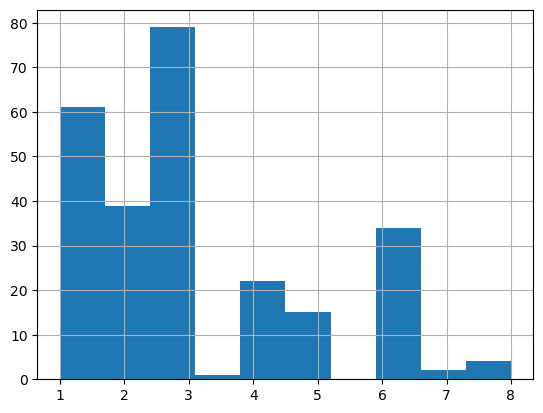

In [48]:
df['Bathrooms'].hist()

In [29]:
import numpy as np

In [30]:
df['Price'] = df['Price'].replace('POA', np.nan)


In [31]:
df = df.dropna(subset=['Price'])

In [32]:
df['Price'].median()

11000000.0

In [33]:
print(df['Price'].describe())

count          256
unique         114
top       10000000
freq            13
Name: Price, dtype: object


In [34]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [35]:
print(df['Price'].describe())

count    2.560000e+02
mean     1.475290e+07
std      1.648902e+07
min      3.000000e+00
25%      7.000000e+06
50%      1.100000e+07
75%      1.660000e+07
max      1.950000e+08
Name: Price, dtype: float64


<Axes: >

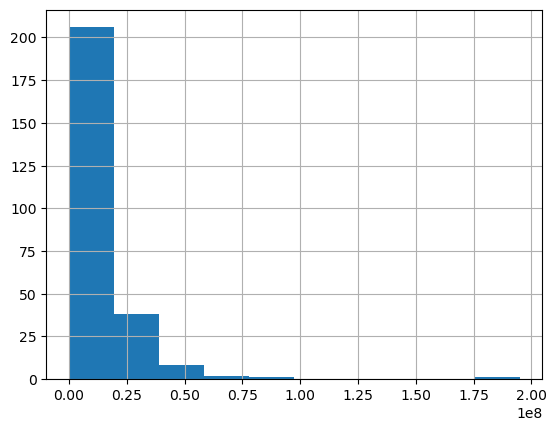

In [62]:
df['Price'].hist()

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


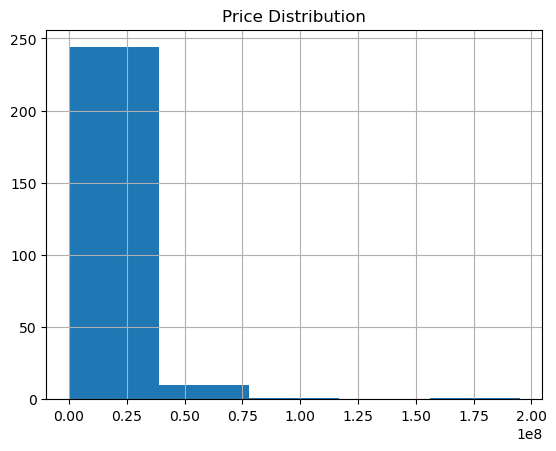

In [37]:
df['Price'].hist(bins=5)
plt.title("Price Distribution")
plt.show()

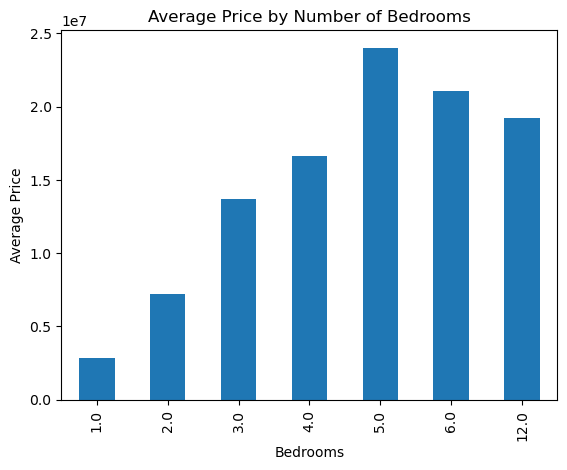

In [67]:
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')

plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.show()

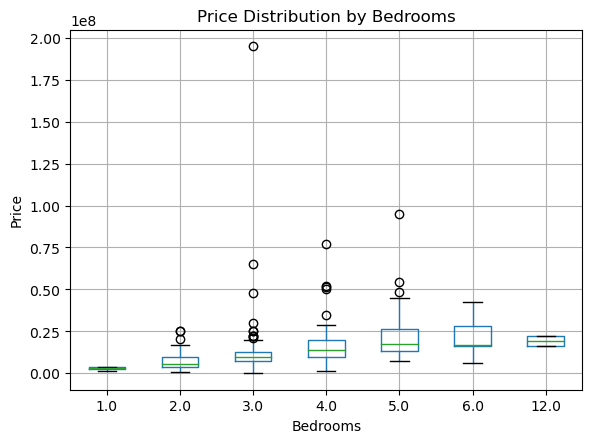

In [38]:
df.boxplot(column='Price', by='Bedrooms')

plt.title("Price Distribution by Bedrooms")
plt.suptitle("")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

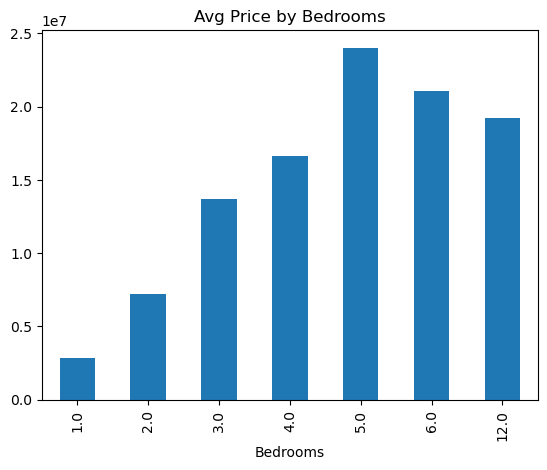

In [69]:
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')
plt.title("Avg Price by Bedrooms")
plt.show()

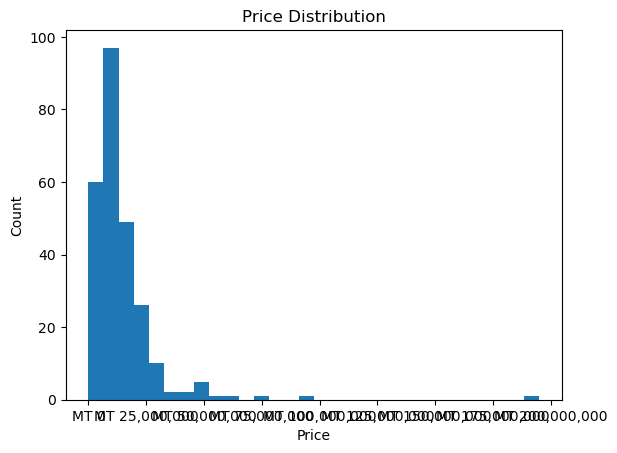

In [39]:
fig, ax = plt.subplots()

ax.hist(df['Price'], bins=30)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"MT {x:,.0f}"))

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

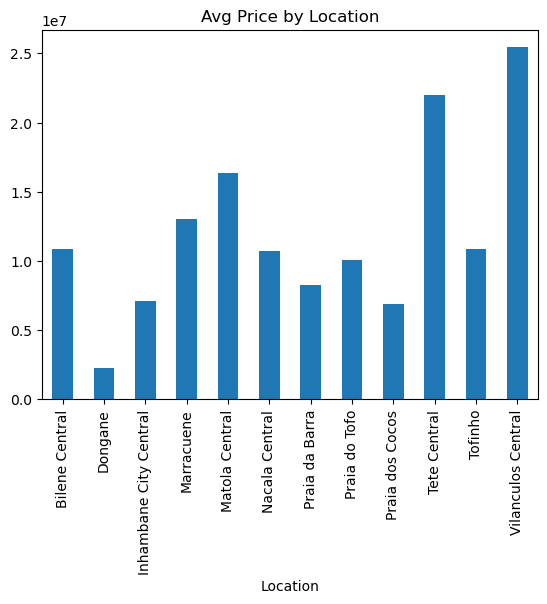

In [75]:
df.groupby('Location')['Price'].mean().plot(kind='bar')
plt.title("Avg Price by Location")
plt.show()

In [40]:
df['Location'].value_counts()

Matola Central            129
Praia do Tofo              29
Tete Central               23
Praia da Barra             21
Bilene Central             17
Vilanculos Central         15
Dongane                    11
Inhambane City Central      4
Nacala Central              4
Tofinho                     1
Praia dos Cocos             1
Marracuene                  1
Name: Location, dtype: int64

In [41]:
# Step 1: define region mapping
region_map = {
    'Matola Central': 'South',
    'Praia do Tofo': 'South',
    'Vilanculos Central': 'South',
    'Bilene Central': 'South',
    'Marracuene': 'South',

    'Tete Central': 'Central',
    'Inhambane City Central': 'Central',

    'Nacala Central': 'North',
    'Dongane': 'North',
    'Tofinho': 'North',
    'Praia dos Cocos': 'North'
}

In [42]:
# Step 2: create region column
df['Region'] = df['Location'].map(region_map)

In [79]:
df.head()

,Page,Title,Price,Location,Address,Description,Bedrooms,Bathrooms,Parking,Floor_Size_m2,URL,Region
0,1,4 Bedroom House,23975000,Bilene Central,"Rua De Marginal, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,1.0,4.0,180 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
1,1,4 Bedroom House,8000000,Bilene Central,"P8R2+52 Praia Do Bilene, Bilene Central, Bilene",Are you searching for your dream property for ...,4.0,3.0,4.0,225 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
2,1,3 Bedroom House,5950000,Bilene Central,"P8X6+WR Praia Do Bilene, Bilene Central, Bilene",Move 2 Moz is incredibly proud to market this ...,3.0,3.0,1.0,145 m²,https://www.property24.co.mz/3-bedroom-house-f...,South
3,1,4 Bedroom House,26000000,Bilene Central,"123 Beach road, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,3.0,4.0,220 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
4,1,5 Bedroom House,7600000,Bilene Central,"Bilene, Bilene Central, Bilene",Discover this unique 5-bedroom beachside home ...,5.0,2.0,4.0,3 500 m²,https://www.property24.co.mz/5-bedroom-house-f...,South


In [80]:
# Step 4: convert to ML-ready format
df = pd.get_dummies(df, columns=['Region'], drop_first=True)

In [82]:
df.head()

,Page,Title,Price,Location,Address,Description,Bedrooms,Bathrooms,Parking,Floor_Size_m2,URL,Region_North,Region_South
0,1,4 Bedroom House,23975000,Bilene Central,"Rua De Marginal, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,1.0,4.0,180 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
1,1,4 Bedroom House,8000000,Bilene Central,"P8R2+52 Praia Do Bilene, Bilene Central, Bilene",Are you searching for your dream property for ...,4.0,3.0,4.0,225 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
2,1,3 Bedroom House,5950000,Bilene Central,"P8X6+WR Praia Do Bilene, Bilene Central, Bilene",Move 2 Moz is incredibly proud to market this ...,3.0,3.0,1.0,145 m²,https://www.property24.co.mz/3-bedroom-house-f...,0,1
3,1,4 Bedroom House,26000000,Bilene Central,"123 Beach road, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,3.0,4.0,220 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
4,1,5 Bedroom House,7600000,Bilene Central,"Bilene, Bilene Central, Bilene",Discover this unique 5-bedroom beachside home ...,5.0,2.0,4.0,3 500 m²,https://www.property24.co.mz/5-bedroom-house-f...,0,1


In [84]:
df.to_csv("cleaned_moz11.csv", index=False)

In [85]:
df.to_excel("cleaned_moz11.xlsx", index=False)

In [88]:
df = df.drop(columns=[
    'Page',
    'Title',
    'Address',
    'Description',
    'URL',
    'Floor_Size_m2'
])

In [89]:
df.head()

,Price,Location,Bedrooms,Bathrooms,Parking,Region_North,Region_South
0,23975000,Bilene Central,4.0,1.0,4.0,0,1
1,8000000,Bilene Central,4.0,3.0,4.0,0,1
2,5950000,Bilene Central,3.0,3.0,1.0,0,1
3,26000000,Bilene Central,4.0,3.0,4.0,0,1
4,7600000,Bilene Central,5.0,2.0,4.0,0,1


In [90]:
df.to_csv("ML_moz.csv", index=False)

In [2]:
import pandas as pd
import numpy as np
import re


In [3]:
# Load data
df = pd.read_excel("housepricemoz.xlsx")

In [4]:
# 1. CLEAN PRICE
df['Price'] = df['Price'].str.replace('MT', '')

In [5]:
df['Price'] = df['Price'].str.replace(' ', '')

In [6]:
# 2. CLEAN FLOOR SIZE
df['Title'].unique


<bound method Series.unique of 0          4 Bedroom House
1       Vacant Land / Plot
2                    House
3       Vacant Land / Plot
4          4 Bedroom House
              ...         
469        2 Bedroom House
470    Commercial Property
471        2 Bedroom House
472        5 Bedroom House
473    Commercial Property
Name: Title, Length: 474, dtype: object>

In [7]:
df = df[df["Title"].str.contains("bedroom", case=False, na=False)]

In [8]:
df["Title"].value_counts()

3 Bedroom House                84
4 Bedroom House                74
2 Bedroom House                40
5 Bedroom House                28
6 Bedroom House                 9
2 Bedroom Apartment / Flat      4
1 Bedroom House                 3
3 Bedroom Apartment / Flat      3
4 Bedroom Townhouse             3
12 Bedroom House                2
12 Bedroom Townhouse            2
4 Bedroom Apartment / Flat      2
16 Bedroom House                1
1 Bedroom Apartment / Flat      1
60 Bedroom Apartment / Flat     1
2 Bedroom Townhouse             1
60 Bedroom House                1
60 Bedroom Townhouse            1
3 Bedroom Townhouse             1
18 Bedroom House                1
72 Bedroom House                1
Name: Title, dtype: int64

In [10]:
df = df[df["Bedrooms"] <= 12]

In [11]:
df.to_csv("cleaned_mozhous.csv", index=False)

In [12]:
df.to_excel("cleaned_mozhous.xlsx", index=False)

In [13]:
df = pd.read_csv('cleaned_mozhouses.csv')

In [14]:
mode = df['Bathrooms'].mode()

In [15]:
mode

0    1.0
Name: Bathrooms, dtype: float64

In [16]:
df['Bathrooms'].mean()

3.0905172413793105

In [15]:
df['Bathrooms'].median()

3.0

In [17]:
df['Bathrooms'].value_counts()  # for specific column

1.0    61
3.0    53
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [18]:
df['Bathrooms'] = df['Bathrooms'].fillna(3)

In [19]:
df['Bathrooms'].value_counts()

3.0    78
1.0    61
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [20]:
df['Location'].value_counts()

Matola Central            129
Praia do Tofo              29
Tete Central               23
Praia da Barra             21
Bilene Central             17
Vilanculos Central         15
Dongane                    11
Inhambane City Central      5
Nacala Central              4
Tofinho                     1
Praia dos Cocos             1
Marracuene                  1
Name: Location, dtype: int64

In [21]:
df.isnull().sum()

Page               0
Title              0
Price              0
Location           0
Address           15
Description        0
Bedrooms           0
Bathrooms          0
Parking          112
Floor_Size_m2     70
URL                0
dtype: int64

In [22]:
df.duplicated().sum() 

0

In [23]:
df['Bathrooms'].value_counts()

3.0    78
1.0    61
2.0    39
6.0    34
4.0    22
5.0    15
8.0     4
7.0     2
3.5     1
2.5     1
Name: Bathrooms, dtype: int64

In [24]:
df['Parking'].mode()

0    4.0
Name: Parking, dtype: float64

In [25]:
df['Parking'].value_counts()

4.0      36
2.0      33
6.0      15
3.0      13
5.0      12
10.0      9
8.0       8
1.0       7
20.0      5
12.0      3
40.0      2
400.0     1
11.0      1
Name: Parking, dtype: int64

In [26]:
df['Parking'] = df['Parking'].fillna(4)

In [27]:
df['Parking'].value_counts()

4.0      148
2.0       33
6.0       15
3.0       13
5.0       12
10.0       9
8.0        8
1.0        7
20.0       5
12.0       3
40.0       2
400.0      1
11.0       1
Name: Parking, dtype: int64

In [28]:
df['Floor_Size_m2'].value_counts()

8 m²        11
2 500 m²    11
7 m²         9
500 m²       7
200 m²       7
            ..
494 m²       1
2 704 m²     1
51 m²        1
125 m²       1
4 800 m²     1
Name: Floor_Size_m2, Length: 97, dtype: int64

<Axes: >

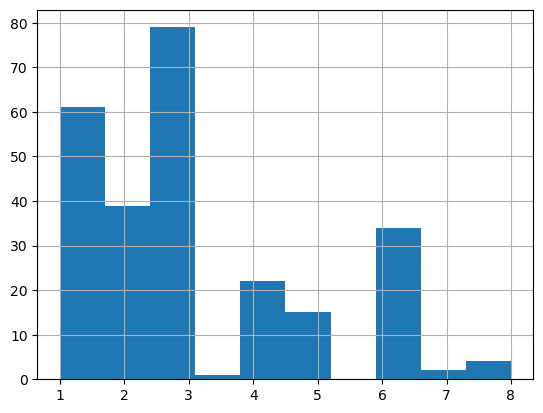

In [48]:
df['Bathrooms'].hist()

In [29]:
import numpy as np

In [30]:
df['Price'] = df['Price'].replace('POA', np.nan)


In [31]:
df = df.dropna(subset=['Price'])

In [32]:
df['Price'].median()

11000000.0

In [33]:
print(df['Price'].describe())

count          256
unique         114
top       10000000
freq            13
Name: Price, dtype: object


In [34]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [35]:
print(df['Price'].describe())

count    2.560000e+02
mean     1.475290e+07
std      1.648902e+07
min      3.000000e+00
25%      7.000000e+06
50%      1.100000e+07
75%      1.660000e+07
max      1.950000e+08
Name: Price, dtype: float64


<Axes: >

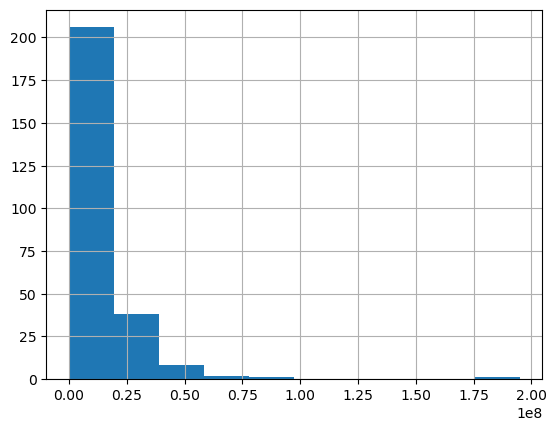

In [62]:
df['Price'].hist()

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


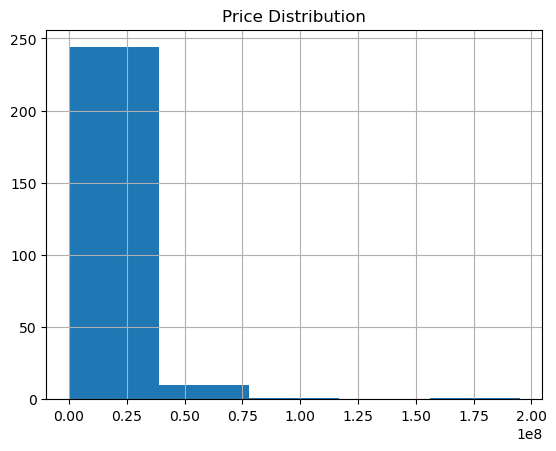

In [37]:
df['Price'].hist(bins=5)
plt.title("Price Distribution")
plt.show()

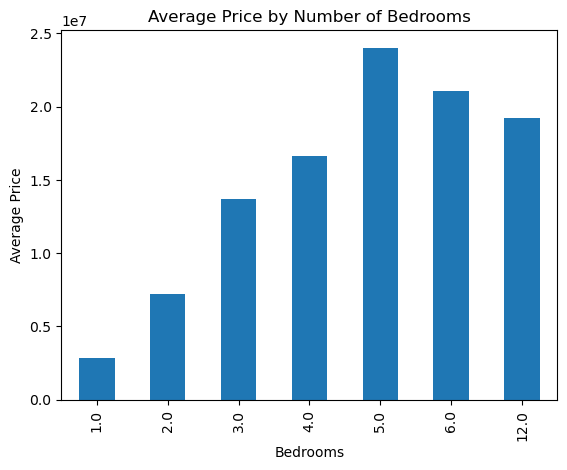

In [67]:
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')

plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.show()

In [1]:
df.boxplot(column='Price', by='Bathrooms')

plt.title("Price Distribution by Bathrooms")
plt.suptitle("")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

NameError: name 'df' is not defined

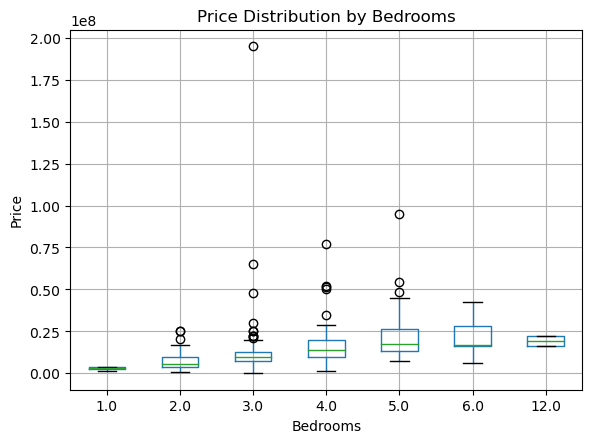

In [38]:
df.boxplot(column='Price', by='Bedrooms')

plt.title("Price Distribution by Bedrooms")
plt.suptitle("")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

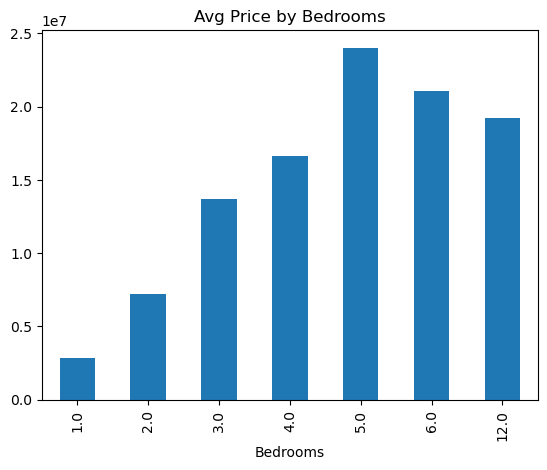

In [69]:
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')
plt.title("Avg Price by Bedrooms")
plt.show()

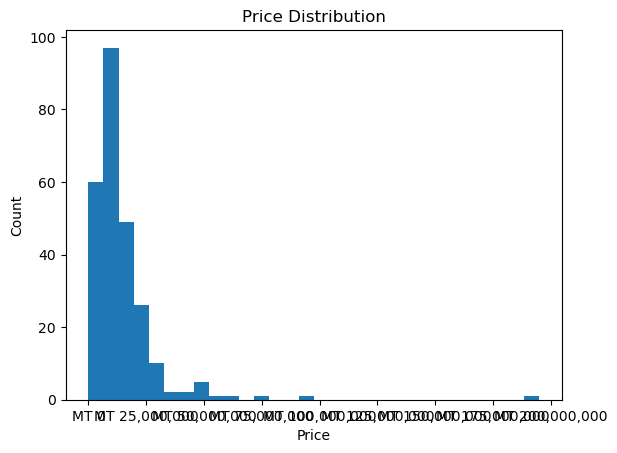

In [39]:
fig, ax = plt.subplots()

ax.hist(df['Price'], bins=30)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"MT {x:,.0f}"))

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

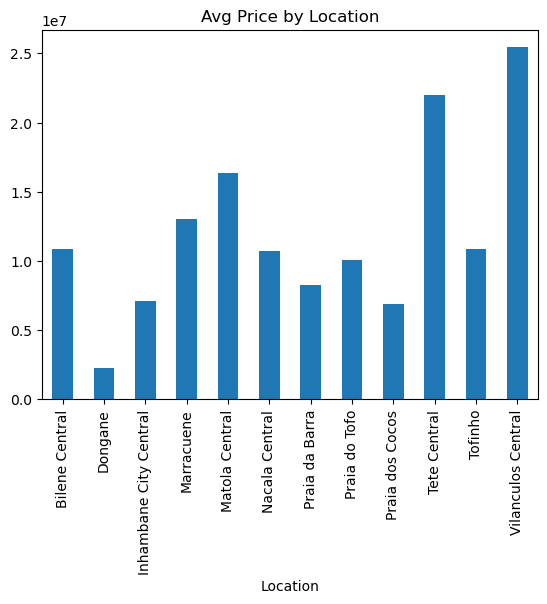

In [75]:
df.groupby('Location')['Price'].mean().plot(kind='bar')
plt.title("Avg Price by Location")
plt.show()

In [40]:
df['Location'].value_counts()

Matola Central            129
Praia do Tofo              29
Tete Central               23
Praia da Barra             21
Bilene Central             17
Vilanculos Central         15
Dongane                    11
Inhambane City Central      4
Nacala Central              4
Tofinho                     1
Praia dos Cocos             1
Marracuene                  1
Name: Location, dtype: int64

In [41]:
# Step 1: define region mapping
region_map = {
    'Matola Central': 'South',
    'Praia do Tofo': 'South',
    'Vilanculos Central': 'South',
    'Bilene Central': 'South',
    'Marracuene': 'South',

    'Tete Central': 'Central',
    'Inhambane City Central': 'Central',

    'Nacala Central': 'North',
    'Dongane': 'North',
    'Tofinho': 'North',
    'Praia dos Cocos': 'North'
}

In [42]:
# Step 2: create region column
df['Region'] = df['Location'].map(region_map)

In [79]:
df.head()

,Page,Title,Price,Location,Address,Description,Bedrooms,Bathrooms,Parking,Floor_Size_m2,URL,Region
0,1,4 Bedroom House,23975000,Bilene Central,"Rua De Marginal, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,1.0,4.0,180 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
1,1,4 Bedroom House,8000000,Bilene Central,"P8R2+52 Praia Do Bilene, Bilene Central, Bilene",Are you searching for your dream property for ...,4.0,3.0,4.0,225 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
2,1,3 Bedroom House,5950000,Bilene Central,"P8X6+WR Praia Do Bilene, Bilene Central, Bilene",Move 2 Moz is incredibly proud to market this ...,3.0,3.0,1.0,145 m²,https://www.property24.co.mz/3-bedroom-house-f...,South
3,1,4 Bedroom House,26000000,Bilene Central,"123 Beach road, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,3.0,4.0,220 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
4,1,5 Bedroom House,7600000,Bilene Central,"Bilene, Bilene Central, Bilene",Discover this unique 5-bedroom beachside home ...,5.0,2.0,4.0,3 500 m²,https://www.property24.co.mz/5-bedroom-house-f...,South


In [80]:
# Step 4: convert to ML-ready format
df = pd.get_dummies(df, columns=['Region'], drop_first=True)

In [82]:
df.head()

,Page,Title,Price,Location,Address,Description,Bedrooms,Bathrooms,Parking,Floor_Size_m2,URL,Region_North,Region_South
0,1,4 Bedroom House,23975000,Bilene Central,"Rua De Marginal, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,1.0,4.0,180 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
1,1,4 Bedroom House,8000000,Bilene Central,"P8R2+52 Praia Do Bilene, Bilene Central, Bilene",Are you searching for your dream property for ...,4.0,3.0,4.0,225 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
2,1,3 Bedroom House,5950000,Bilene Central,"P8X6+WR Praia Do Bilene, Bilene Central, Bilene",Move 2 Moz is incredibly proud to market this ...,3.0,3.0,1.0,145 m²,https://www.property24.co.mz/3-bedroom-house-f...,0,1
3,1,4 Bedroom House,26000000,Bilene Central,"123 Beach road, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,3.0,4.0,220 m²,https://www.property24.co.mz/4-bedroom-house-f...,0,1
4,1,5 Bedroom House,7600000,Bilene Central,"Bilene, Bilene Central, Bilene",Discover this unique 5-bedroom beachside home ...,5.0,2.0,4.0,3 500 m²,https://www.property24.co.mz/5-bedroom-house-f...,0,1


In [84]:
df.to_csv("cleaned_moz11.csv", index=False)

In [85]:
df.to_excel("cleaned_moz11.xlsx", index=False)

In [88]:
df = df.drop(columns=[
    'Page',
    'Title',
    'Address',
    'Description',
    'URL',
    'Floor_Size_m2'
])

In [89]:
df.head()

,Price,Location,Bedrooms,Bathrooms,Parking,Region_North,Region_South
0,23975000,Bilene Central,4.0,1.0,4.0,0,1
1,8000000,Bilene Central,4.0,3.0,4.0,0,1
2,5950000,Bilene Central,3.0,3.0,1.0,0,1
3,26000000,Bilene Central,4.0,3.0,4.0,0,1
4,7600000,Bilene Central,5.0,2.0,4.0,0,1


In [90]:
df.to_csv("ML_moz.csv", index=False)